# Phase 11: A procedure that is monotone in the label budget

CPU only. Attach `phase-1-sep-14` and `phase-6-sep-15`.

## What is wrong with Phase 9

Look at ResNet, severity 3, the `eff` column: 0.31, 0.48, 0.57, 0.41, 0.31, 0.20.
It peaks at n=500 and then **declines** as you add labels. More data making a
procedure worse is impossible if the procedure is correct, so the procedure is
wrong. My design was the error.

The cause is the ordering. Phase 9 walked from the strictest threshold down and
stopped at the first failure. At the strictest thresholds only a handful of
labelled points are accepted, and no bound can certify 5% risk from two or three
observations no matter how clean they are. So the walk terminated almost
immediately, and where it terminated depended on how many points happened to land
in the extreme tail. That is noise, not signal.

Fixed sequence testing is only valid *and useful* when the early hypotheses are
reliably rejectable. Here they are structurally un-rejectable.

## The fix

Go back to Phase 8's structure, which was correct, and only repair its actual
defect: the Bonferroni factor of 100 was far too harsh. Use a coarse grid of 20
candidates set from validation quantiles, scan from loosest to strictest, and take
the first candidate whose bound clears the target. That is the maximum coverage
choice, it is valid at `ALPHA`, and it is monotone in n by construction.

In [1]:
import glob, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.stats import beta

F1=glob.glob("/kaggle/input/**/logits.npz",recursive=True)[0]
F2=glob.glob("/kaggle/input/**/logits2.npz",recursive=True)[0]
d1,d2=np.load(F1),np.load(F2); SEEDS=[0,1,2]; TG=0.05; ALPHA=0.10
STD15=["gaussian_noise","shot_noise","impulse_noise","defocus_blur","glass_blur",
       "motion_blur","zoom_blur","snow","frost","fog","brightness","contrast",
       "elastic_transform","pixelate","jpeg_compression"]
def softmax(z,T=1.0):
    z=z.astype(np.float64)/T; z-=z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)
def nll(p,y): return -np.log(np.clip(p[np.arange(len(y)),y],1e-12,None)).mean()
def ep(m,T): return np.mean([softmax(x,T) for x in m],0)
def rv(a): return [d2[f"wrn_val_{s}"] if a=="wrn" else d1[f"val_{s}"] for s in SEEDS]
def rl(a,cc,sv): return [d2[f"wrn_{cc}_{sv}_{s}"] if a=="wrn" else d1[f"{cc}_{sv}_{s}"] for s in SEEDS]
Y_VAL,Y_CORR=d1["y_val"],d1["y_corr"]
T_={a:minimize_scalar(lambda t,a=a: nll(ep(rv(a),t),Y_VAL),bounds=(.5,10),method="bounded").x
    for a in ("res","wrn")}
PVAL={a:ep(rv(a),T_[a]) for a in ("res","wrn")}
P={(a,cc,sv):(ep(rl(a,cc,sv),T_[a]),Y_CORR) for a in ("res","wrn") for cc in STD15 for sv in range(1,6)}

# grid fixed in advance from VALIDATION confidences, never from the shifted sample
K=20
GRID={a:np.quantile(PVAL[a].max(1),np.linspace(0.02,0.98,K)) for a in ("res","wrn")}
ALPHA_C=ALPHA/K
NMIN=int(np.ceil(np.log(ALPHA_C)/np.log(1-TG)))
print(f"grid size {K}, per-candidate alpha {ALPHA_C:.4f}")
print(f"minimum accepted labels needed to certify {TG:.0%} risk with zero errors: {NMIN}")

grid size 20, per-candidate alpha 0.0050
minimum accepted labels needed to certify 5% risk with zero errors: 104


## 1. Procedure

Scan loosest to strictest, return the first candidate that clears. Monotone in n:
more labels tighten every bound, so a candidate that cleared with n labels still
tends to clear with more, and the chosen threshold moves loosewards.

In [2]:
def cp_up(k,n,al):
    if n==0: return 1.0
    return 1.0 if k==n else beta.ppf(1-al,k+1,n-k)

def select(pr,y,idx,arch,target=TG):
    cf=pr[idx].max(1); wrong=pr[idx].argmax(1)!=y[idx]
    for t in GRID[arch]:                         # ascending = loosest first
        a=cf>=t
        if a.sum()==0: continue
        if cp_up(wrong[a].sum(),a.sum(),ALPHA_C)<=target:
            return t                             # max coverage that clears
    return np.inf                                # abstain on everything

def evaluate(pr,y,thr):
    a=pr.max(1)>=thr
    if a.sum()==0: return 0.0,0.0,True
    return 1-(pr.argmax(1)[a]==y[a]).mean(), a.mean(), False

def oracle_cov(pr,y,t=TG):
    cf=pr.max(1); o=np.argsort(-cf)
    r=1-np.cumsum(pr.argmax(1)[o]==y[o])/np.arange(1,len(o)+1)
    ok=np.where(r<=t+1e-9)[0]
    return 0.0 if len(ok)==0 else (ok[-1]+1)/len(o)

## 2. Label budget, and a monotonicity check

`mono` flags any case where efficiency fell relative to the previous smaller
budget. It should be empty. If it is not, the procedure is still broken and
nothing downstream should be reported.

In [3]:
rng=np.random.default_rng(0); BUD=[100,250,500,1000,2000,4000]; TR=20
out={}; bad=[]
print(f"{'arch':>4} {'sev':>3} {'n':>5} {'risk':>7} {'cov':>7} {'oracle':>7} {'eff':>6} {'viol':>6} {'abst':>6}")
for a in ("res","wrn"):
    for sev in [3,5]:
        prev=None
        for n in BUD:
            rs,cs,vs,ab,oc=[],[],[],[],[]
            for cc in STD15:
                pr,y=P[(a,cc,sev)]; oc.append(oracle_cov(pr,y))
                for _ in range(TR):
                    i=rng.permutation(len(y)); t=select(pr,y,i[:n],a)
                    r,cv,z=evaluate(pr[i[n:]],y[i[n:]],t)
                    rs.append(r); cs.append(cv); vs.append(r>TG); ab.append(z)
            o=np.mean(oc); cv=np.mean(cs); eff=cv/o
            out[(a,sev,n)]=(np.mean(rs),cv,o,np.mean(vs),np.mean(ab),eff)
            if prev is not None and eff < prev-0.02: bad.append((a,sev,n))
            prev=eff
            print(f"{a:>4} {sev:>3} {n:>5} {np.mean(rs):>7.3f} {cv:>7.3f} {o:>7.3f} "
                  f"{eff:>6.2f} {np.mean(vs)*100:>5.0f}% {np.mean(ab)*100:>5.0f}%")
print("\nnon-monotone cases:", bad if bad else "none")

arch sev     n    risk     cov  oracle    eff   viol   abst
 res   3   100   0.000   0.000   0.584   0.00     0%   100%
 res   3   250   0.005   0.225   0.584   0.39     0%    66%
 res   3   500   0.011   0.374   0.584   0.64     0%    37%
 res   3  1000   0.016   0.442   0.584   0.76     0%    27%
 res   3  2000   0.022   0.481   0.584   0.82     0%    21%
 res   3  4000   0.025   0.498   0.584   0.85     1%    15%
 res   5   100   0.000   0.000   0.264   0.00     0%   100%
 res   5   250   0.001   0.049   0.264   0.18     0%    93%
 res   5   500   0.003   0.084   0.264   0.32     0%    82%
 res   5  1000   0.008   0.138   0.264   0.52     0%    64%
 res   5  2000   0.012   0.178   0.264   0.67     0%    51%
 res   5  4000   0.017   0.205   0.264   0.78     0%    44%
 wrn   3   100   0.000   0.000   0.536   0.00     0%   100%
 wrn   3   250   0.003   0.178   0.536   0.33     0%    73%
 wrn   3   500   0.009   0.318   0.536   0.59     0%    43%
 wrn   3  1000   0.015   0.399   0.536  

## 3. Why the budget is what it is

Phase 9 section 4 pointed at the real mechanism: what matters is not n, but how
many labels land **inside the accepted region**. Certifying 5% risk needs at
least `NMIN` accepted labels even with zero observed errors. Since the accepted
region has size roughly equal to the oracle coverage, the required budget should
scale as `NMIN / oracle_coverage`.

That predicts something specific and testable: the harder the shift, the more
labels you need, because achievable coverage shrinks. Labels get more expensive
exactly when they are hardest to obtain.

In [4]:
print(f"{'arch':>4} {'sev':>3} {'oracle cov':>11} {'predicted n':>12} {'empirical n (eff>=0.8)':>23}")
for a in ("res","wrn"):
    for sev in [1,2,3,4,5]:
        o=np.mean([oracle_cov(*P[(a,cc,sev)]) for cc in STD15])
        pred=NMIN/o if o>0 else np.inf
        emp="-"
        if sev in (3,5):
            hit=[n for n in BUD if out[(a,sev,n)][5]>=0.80 and out[(a,sev,n)][3]<=ALPHA]
            emp=str(hit[0]) if hit else f">{BUD[-1]}"
        print(f"{a:>4} {sev:>3} {o:>11.3f} {pred:>12.0f} {emp:>23}")

arch sev  oracle cov  predicted n  empirical n (eff>=0.8)
 res   1       0.833          125                       -
 res   2       0.696          149                       -
 res   3       0.584          178                    2000
 res   4       0.458          227                       -
 res   5       0.264          394                   >4000
 wrn   1       0.800          130                       -
 wrn   2       0.651          160                       -
 wrn   3       0.536          194                    2000
 wrn   4       0.404          257                       -
 wrn   5       0.230          451                   >4000


## 4. Figure

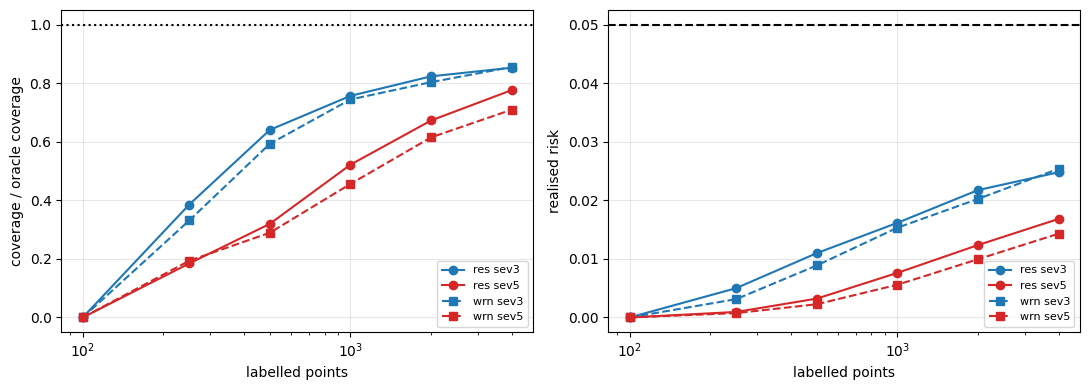

In [5]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
for a,ls in (("res","o-"),("wrn","s--")):
    for sev,col in ((3,"tab:blue"),(5,"tab:red")):
        ax[0].plot(BUD,[out[(a,sev,n)][5] for n in BUD],ls,c=col,label=f"{a} sev{sev}")
        ax[1].plot(BUD,[out[(a,sev,n)][0] for n in BUD],ls,c=col,label=f"{a} sev{sev}")
ax[0].axhline(1.0,ls=":",c="k"); ax[0].set_ylabel("coverage / oracle coverage")
ax[1].axhline(TG,ls="--",c="k"); ax[1].set_ylabel("realised risk")
for x in ax: x.set_xscale("log"); x.set_xlabel("labelled points"); x.grid(alpha=.3); x.legend(fontsize=8)
plt.tight_layout(); plt.show()

## What to report

If `non-monotone cases` is `none`, this is the version that goes in the paper and
Phase 9 gets discarded.

Two numbers for the abstract: the budget at which efficiency reaches 0.8, and the
violation rate (which should sit at or below 10%). If the empirical budget tracks
`NMIN / oracle_coverage`, say so; a simple formula that predicts the label cost is
a better contribution than a table of measurements.